In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import os
sys.path.append(os.path.abspath("/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main"))

In [4]:
import pandas as pd 
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from collections import defaultdict

In [5]:
data = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope_COMBATT_randeff.csv')

In [6]:
import pandas as pd
from scipy.stats import ttest_ind
rows = []
for _, row in data.iterrows():
    genes = [g.strip() for g in str(row['mutated_genes']).split(',')]#replace('&', ',').split(',')]
    for gene in genes:
        new_row = row.copy()
        new_row['mutated_genes'] = gene
        rows.append(new_row)
data = pd.DataFrame(rows).reset_index(drop=True)

data_clean = data.dropna(subset=['y2_slope', 'mutated_genes', 'plate', 'light_regime'])

genes_to_test = (
    data_clean[data_clean['mutated_genes'] != 'WT']
    [['light_regime', 'mutated_genes']]
    .drop_duplicates()
    .rename(columns={'mutated_genes': 'gene'})
)

results = []

for _, row in genes_to_test.iterrows():
    regime = row['light_regime']
    gene = row['gene']
    
    plates_with_gene = data_clean[
        (data_clean['light_regime'] == regime) &
        (data_clean['mutated_genes'] == gene)
    ]['plate'].unique()
    
    subset = data_clean[
        (data_clean['light_regime'] == regime) &
        (data_clean['plate'].isin(plates_with_gene)) &
        (data_clean['mutated_genes'].isin(['WT', gene]))
    ]
    
    mutant_vals = subset[subset['mutated_genes'] == gene]['y2_slope']
    wt_vals = subset[subset['mutated_genes'] == 'WT']['y2_slope']
    
    if len(mutant_vals) > 1 and len(wt_vals) > 1:
        stat, pval = ttest_ind(mutant_vals, wt_vals, equal_var=False)
    else:
        stat, pval = None, None

    results.append({
        'light_regime': regime,
        'gene': gene,
        'mutant_mean': mutant_vals.mean() if len(mutant_vals) > 0 else None,
        'wt_mean': wt_vals.mean() if len(wt_vals) > 0 else None,
        'p_value': pval,
        'n_mutant': len(mutant_vals),
        'n_wt': len(wt_vals)
    }) 
results_df = pd.DataFrame(results)
print(results_df)

     light_regime                           gene  mutant_mean   wt_mean  \
0       1min-1min                  Cre07.g322350    -0.000931  0.000060   
1       1min-1min                  Cre01.g023050    -0.000932  0.000060   
2       1min-1min                  Cre01.g025400    -0.000147  0.000060   
3       1min-1min  Cre01.g025450 & Cre01.g025500    -0.000051  0.000060   
4       1min-1min                  Cre03.g200500    -0.001003 -0.000938   
...           ...                            ...          ...       ...   
5072  10min-10min                  Cre17.g721350    -0.008263 -0.007305   
5073  10min-10min                  Cre04.g228850    -0.008089 -0.007305   
5074  10min-10min                  Cre15.g635350    -0.007366 -0.007305   
5075  10min-10min                  Cre17.g705750    -0.008982 -0.007305   
5076  10min-10min                  Cre04.g214097    -0.008000 -0.007305   

           p_value  n_mutant  n_wt  
0     2.620983e-02         9    20  
1     1.125677e-03       

In [7]:
results_df = results_df.sort_values('p_value')
results_df['rank'] = np.arange(1, len(results_df) + 1)
results_df['BH_threshold'] = (results_df['rank'] / len(results_df)) * 0.05
results_df['significant'] = results_df['p_value'] < results_df['BH_threshold']
significant_data = results_df[results_df['significant']]


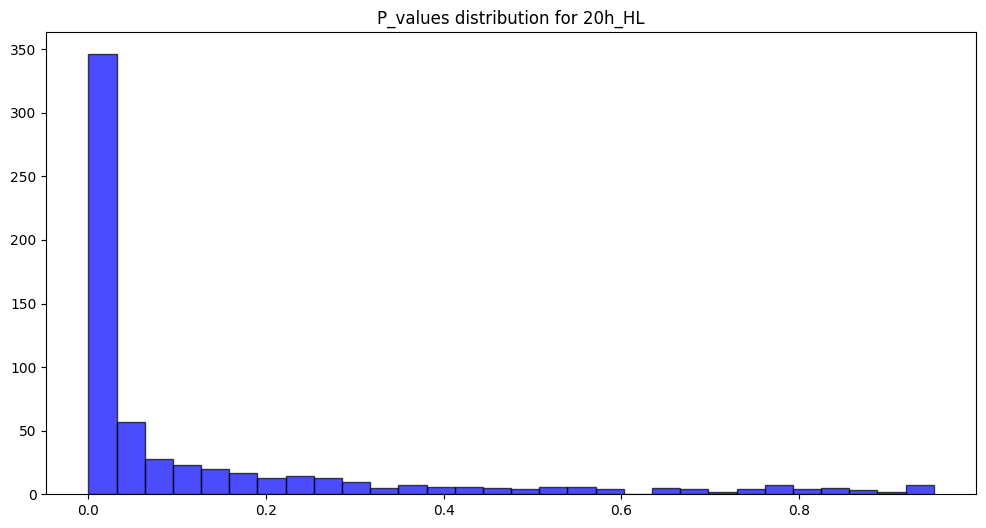

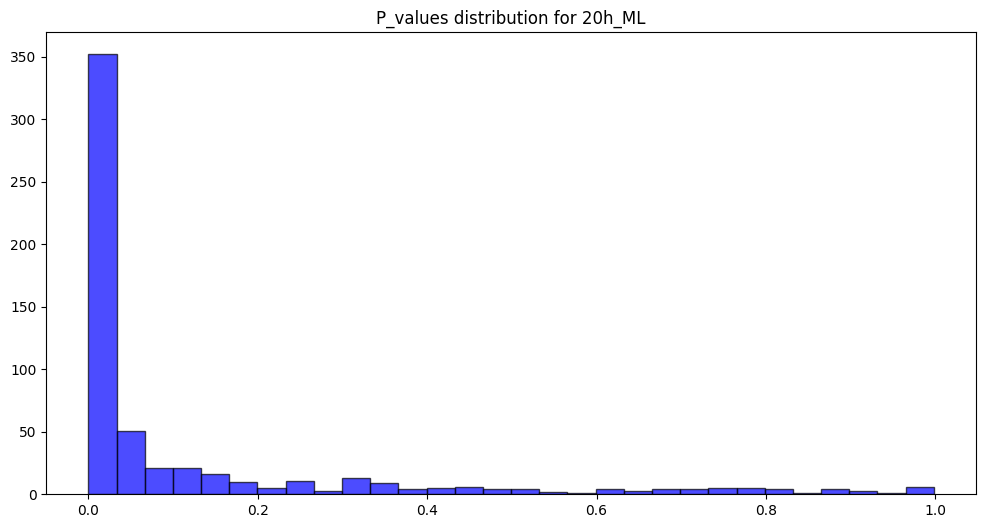

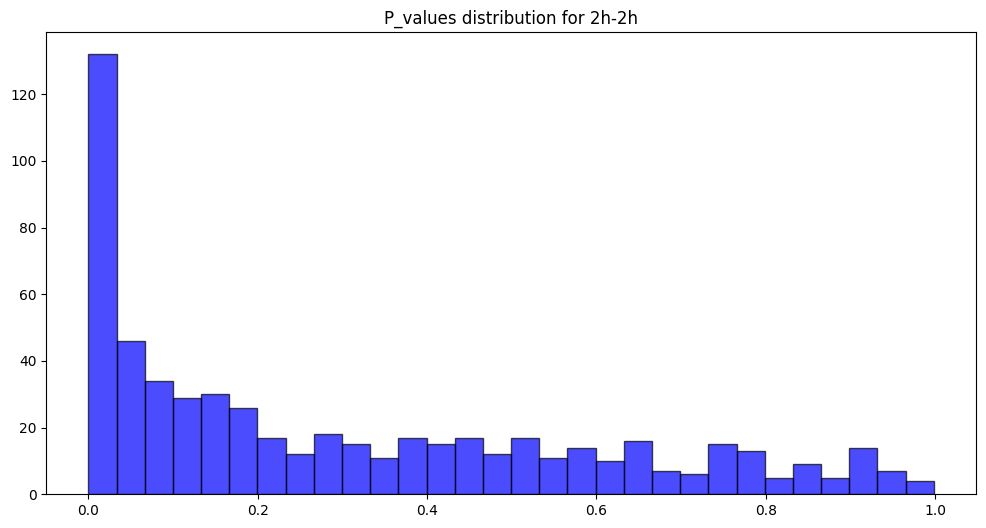

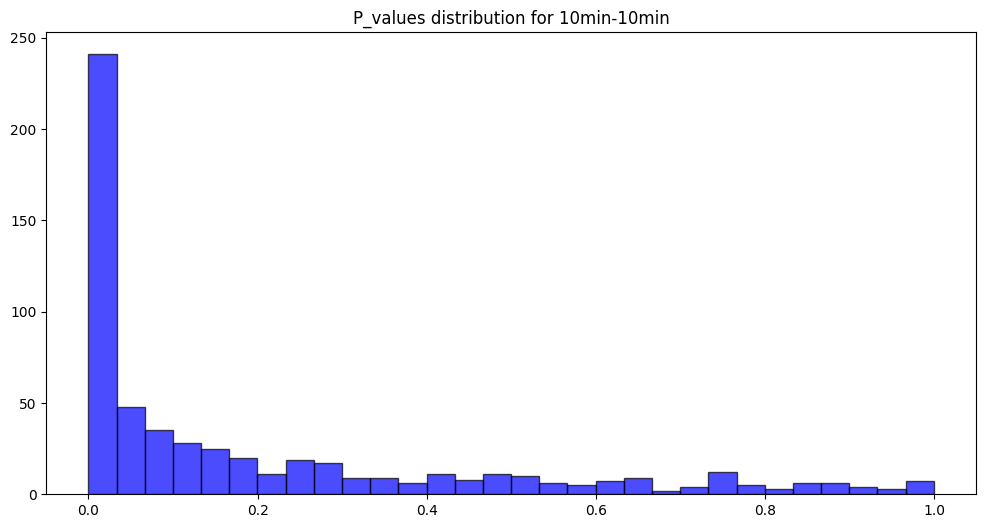

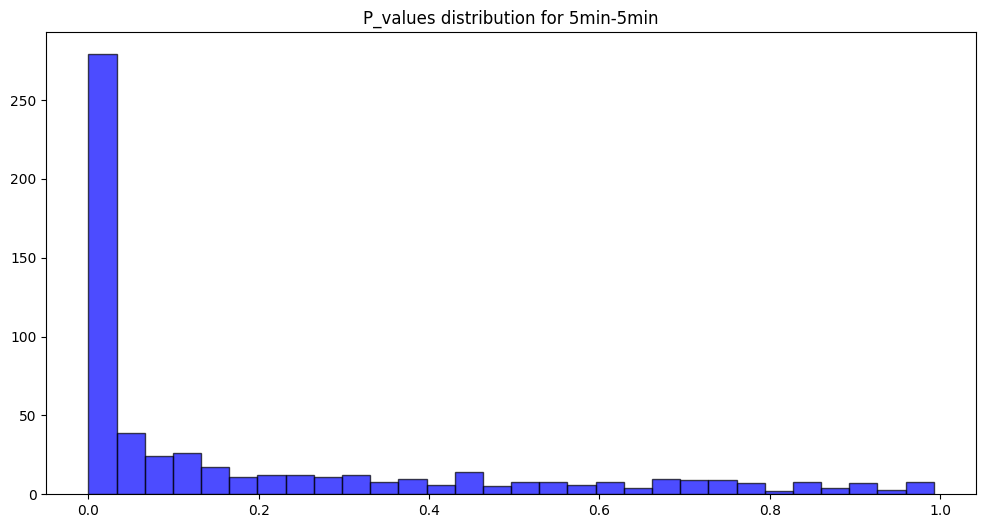

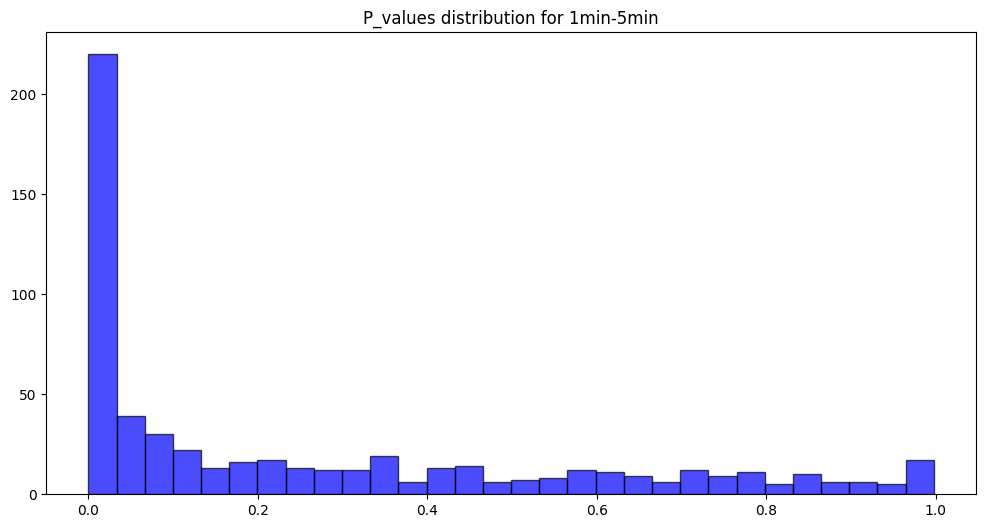

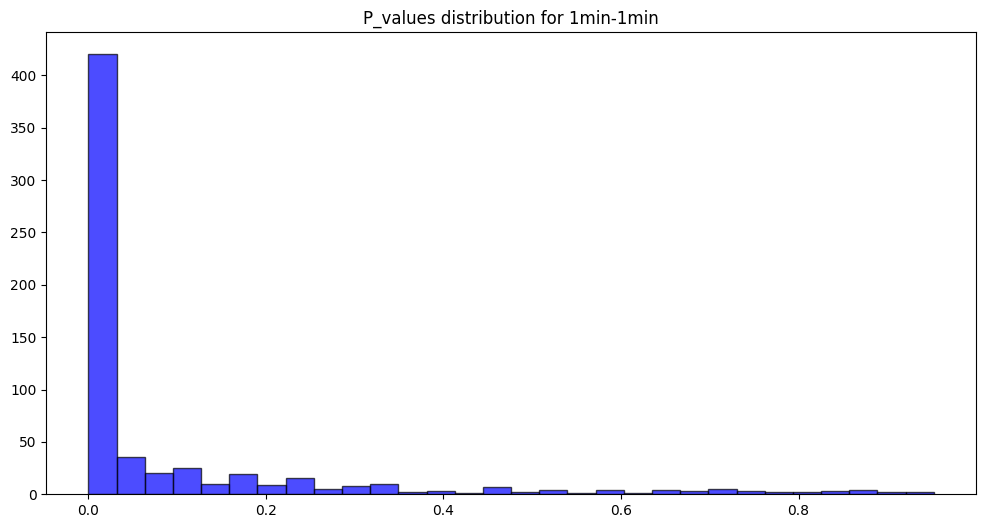

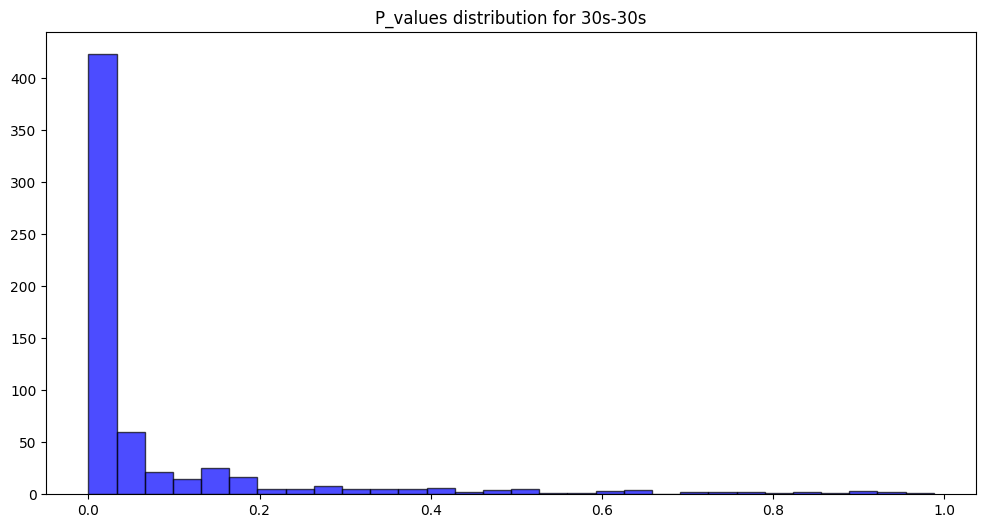

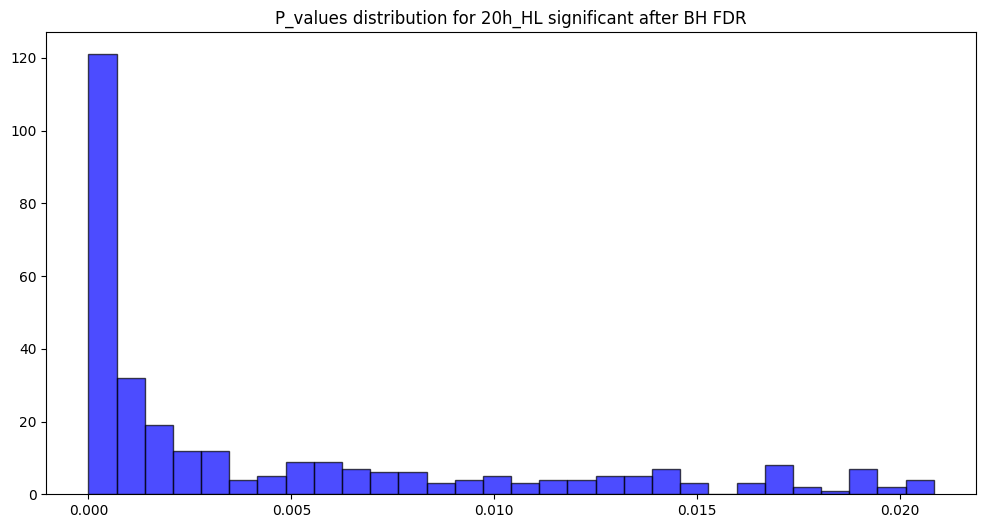

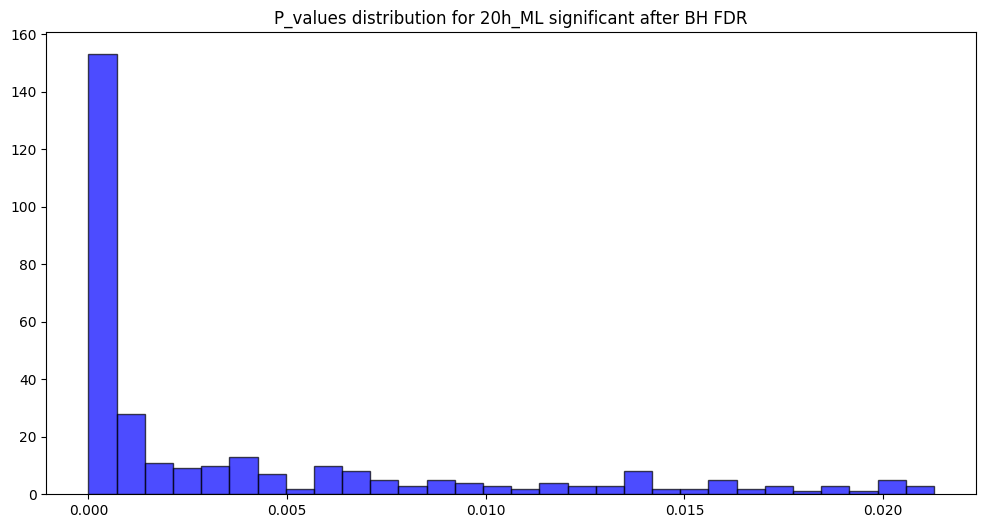

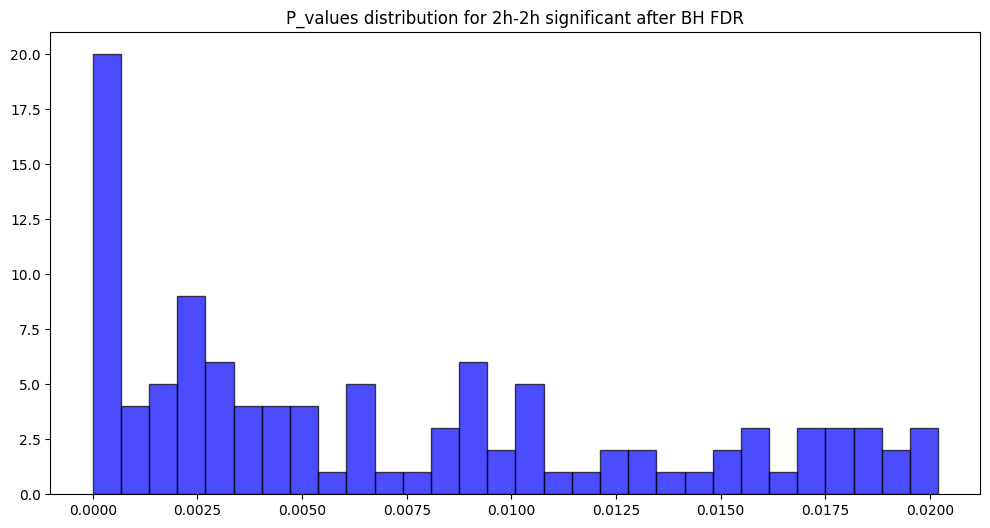

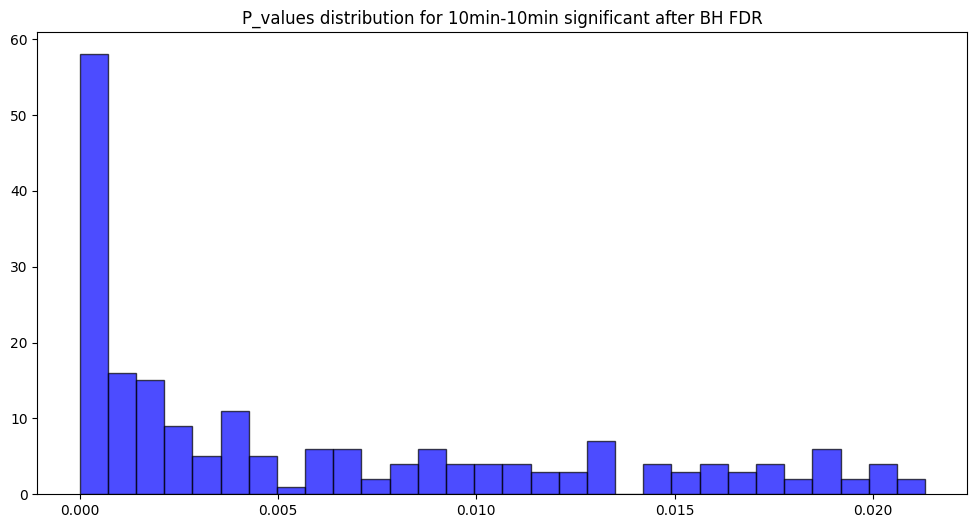

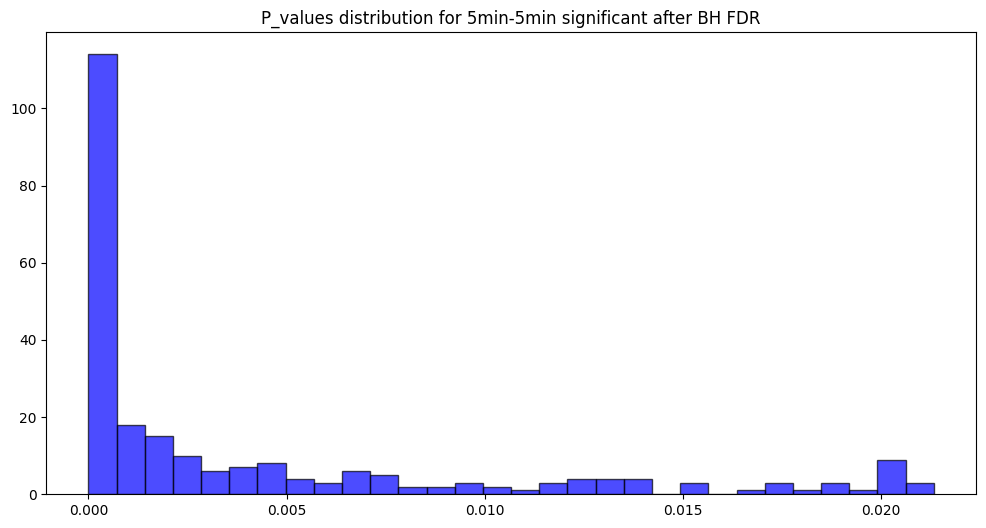

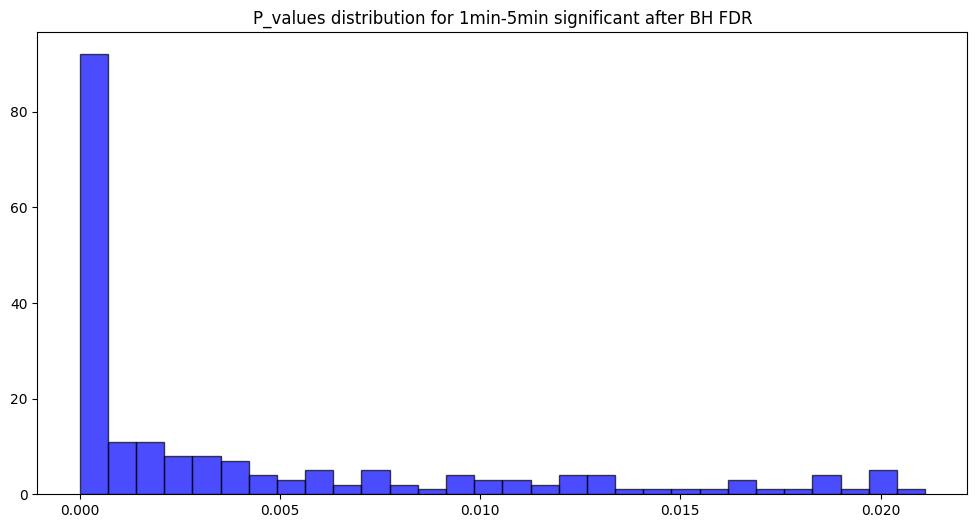

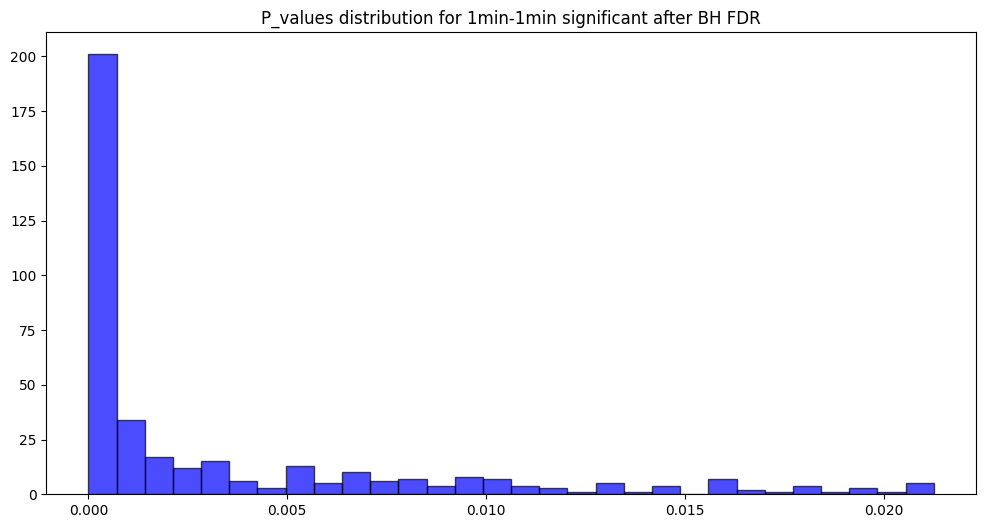

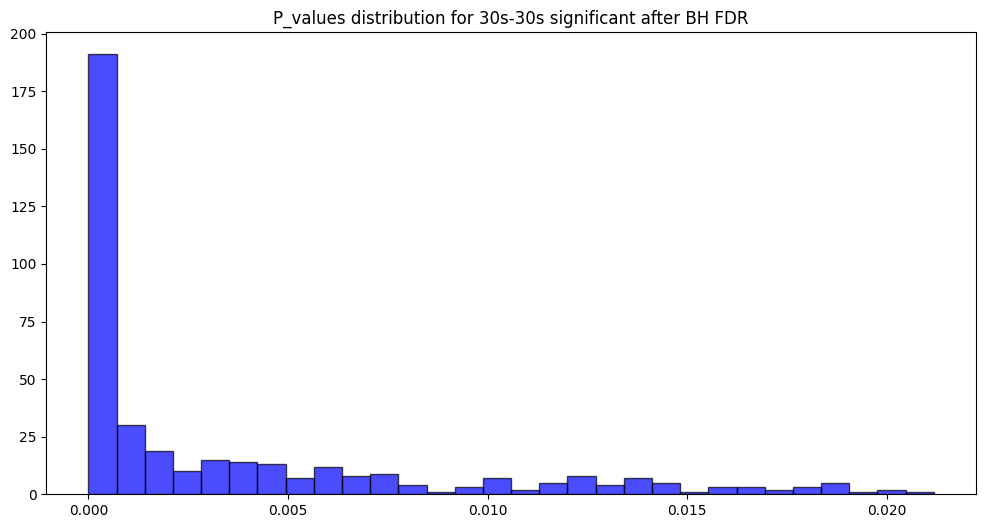

In [8]:
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
for light in light_regimes:
    subset = results_df[results_df['light_regime'] == light]
    plt.figure(figsize=(12,6))
    plt.hist(subset['p_value'], bins=30, alpha=0.7,color='blue',edgecolor='black')
    plt.title(f'P_values distribution for {light}')
for light in light_regimes:
    subset = significant_data[significant_data['light_regime'] == light]
    plt.figure(figsize=(12,6))
    plt.hist(subset['p_value'], bins=30, alpha=0.7,color='blue',edgecolor='black')
    plt.title(f'P_values distribution for {light} significant after BH FDR')


In [9]:
print(len(results_df[results_df['p_value'] < 0.05]['gene'].unique()))
print(len(significant_data['gene'].unique()))
print(len(data['mutated_genes'].unique()))

619
604
639


### Slope cluster from the box plot (+1 or -1 or 0 around WT confidence interval)

In [ ]:
result = pd.read_csv('/home/imokhtatif/.vscode-server/Chlamy_Project_v2-main/Data/2025_5_phase2_light_status_slope_COMBATT_randeff_slope_cluster_y2.csv')

In [1]:
light_regimes = ['20h_HL', '20h_ML', '2h-2h', '10min-10min', '5min-5min', '1min-5min', '1min-1min', '30s-30s']
set_of_genes = set()
overall_count = 0
for light in light_regimes:
    subset = result[result['light_regime'] == light]
    light_count = 0
    for gene in subset['mutated_genes'].unique():
        subset_gene = subset[subset['mutated_genes'] == gene]
        if len(set(subset_gene['slope_cluster_y2'])) == 1:
            #print(f"Gene {gene} is consistent across all mutants in cluster :{set(subset_gene['slope_cluster_y2'])}")
            if set(subset_gene['slope_cluster_y2']) != {0}:
                set_of_genes.add(gene)
                light_count+=1
    print(f"Number of consistent genes for {light} : {light_count}")
    overall_count += light_count
print(f"Total number of consistent outlier genes across all light regimes: {overall_count}")
print(f"Total number of unique consistent outlier genes across all light regimes: {len(set_of_genes)}")

NameError: name 'result' is not defined